# Bayesian Model Comparison with COMPASS

This notebook walks you through the process of performing Bayesian model comparison (BMC) with the `compass` package on a simple toy problem.

**Goal** <br>
Often in science, we have several competing theories—or models—that could explain our data. <br>
BMC is a principled way to ask: "Given the data I've observed, which of these models is the most plausible?"

**Tool** <br>
`compass` leverages a powerful combination of diffusion models and transformers to learn the behavior of complex simulators.<br>
At its core, it uses a `ScoreBasedInferenceModel` to create a fast and accurate neural surrogate for a given simulator. <br>
For the model comparison, we'll use the `ModelTransfuser` class, a high-level manager that automates the process of training surrogates for multiple competing models and evaluating them against new data to find the most plausible explanation.

**Toy Problem**<br>
We will define three simple "simulators" (Hypotheses 1, 2, and 3).<br>
Our task is to generate data from Hypothesis 1 and see if `compass` can correctly identify it as the true model.

In [ ]:
import torch
import torch.nn as nn
import numpy as np

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from compass import ScoreBasedInferenceModel as SBIm
from compass import ModelTransfuser as MTf

## Competing Models/Simulators
First, we need to define our competing hypotheses. <br>
Each hypothesis is a simulator, represented here as a function that can generate data.<br>
All three of our models will share a common structure: a single parameter $\theta$, influences two observable quantities, $x_1$ and $x_2$.<br>

Our task is to distinguish between them based on observed data.

### Hypothesis 1
This is the model we will use to generate our test data.
$$ \begin{align*}
    \theta &\sim \mathcal{N}(0, 3^2) \\
    x_1 &\sim \mathcal{N}(2 \cdot \sin(\theta), 0.5^2) \\
    x_2 &\sim \mathcal{N}(0.1 \cdot \theta^2, (0.5 \cdot |x_1|)^2)
\end{align*} $$

### Hypothesis 2
This model is a plausible alternative. It's structurally identical to Hypothesis 1, but the periodic relationship is phase-shifted. <br>
This is a classical model comparison problem, can we distinguish between two very similar models?
$$ \begin{align*}
    \theta &\sim \mathcal{N}(0, 3^2) \\
    x_1 &\sim \mathcal{N}(0.1 \cdot \theta^2, 0.5^2) \\
    x_2 &\sim \mathcal{N}(2 \cdot \cos(\theta), 0.5^2)
\end{align*} $$

### Hypothesis 3
This model is a more radical departure from the first two. Here, $x_1$ and $x_2$ are independent of $\theta$. <br>
It acts as a "null hypothesis" or baseline model, to determine if our framework correctly rejects a model that has no explanatory power.
$$ \begin{align*}
    \theta &\sim \mathcal{N}(0, 3^2) \\
    x_1 &\sim \mathcal{N}(0, 1^2) \\
    x_2 &\sim |\mathcal{N}(0, 2^2)|
\end{align*} $$

In [2]:
# Define the data generation functions

# Hypothesis 1
def gen_data_hyp1(int):
    theta = 3 * torch.randn(int)
    x1 = 2 * torch.sin(theta) + torch.randn(int) * 0.5
    x2 = 0.1 * theta**2 + 0.5*torch.abs(x1) * torch.randn(int)

    return theta.unsqueeze(1), torch.stack([x1, x2],dim=1)

# Hypothesis 2
def gen_data_hyp2(int):
    theta = 3 * torch.randn(int)
    x1 = 0.1 * theta**2 + 0.5*torch.randn(int)
    x2 = 2 * torch.cos(theta) + torch.randn(int) * 0.5
    return theta.unsqueeze(1), torch.stack([x1, x2],dim=1)

# Hypothesis 3
def gen_data_hyp3(int):
    theta = 3 * torch.randn(int)
    x1 = torch.randn(int)
    x2 = torch.abs(torch.randn(int)) * 2

    return theta.unsqueeze(1), torch.stack([x1, x2],dim=1)

In [3]:
# Generate training and validation data from the simulators

theta1, x1 = gen_data_hyp1(100_000)
val_theta1, val_x1 = gen_data_hyp1(1_000)

theta2, x2 = gen_data_hyp2(100_000)
val_theta2, val_x2 = gen_data_hyp2(1_000)

theta3, x3 = gen_data_hyp3(100_000)
val_theta3, val_x3 = gen_data_hyp3(1_000)

nodes_max = theta1.shape[1] + x1.shape[1]

In [4]:
# After generating data, normalize everything
all_data = torch.cat([torch.cat([theta1, x1], dim=1),
                      torch.cat([theta2, x2], dim=1),
                      torch.cat([theta3, x3], dim=1)], dim=0)
data_mean = all_data.mean(0)
data_std = all_data.std(0)

def normalize(theta, x):
    joint = torch.cat([theta, x], dim=1)
    joint_norm = (joint - data_mean) / data_std
    return joint_norm[:, :1], joint_norm[:, 1:]

def unnormalize_x(x_norm):
    return x_norm * data_std[1:] + data_mean[1:]

# Normalize all training data
theta1_n, x1_n = normalize(theta1, x1)
theta2_n, x2_n = normalize(theta2, x2)
theta3_n, x3_n = normalize(theta3, x3)

# Normalize all validation data
val_theta1_n, val_x1_n = normalize(val_theta1, val_x1)
val_theta2_n, val_x2_n = normalize(val_theta2, val_x2)
val_theta3_n, val_x3_n = normalize(val_theta3, val_x3)


Let's visualize the data generated by our three simulators. <br>
The `sns.pairplot` shows the joint distributions of ($\theta$, $x_1$, $x_2$) for each hypothesis.

In [5]:
# flip palette to have Hyp1 in blue, Hyp2 in orange, Hyp3 in green
palette = sns.color_palette("dark", 3)
palette = [palette[2], palette[1], palette[0]]

<Figure size 3000x3000 with 0 Axes>

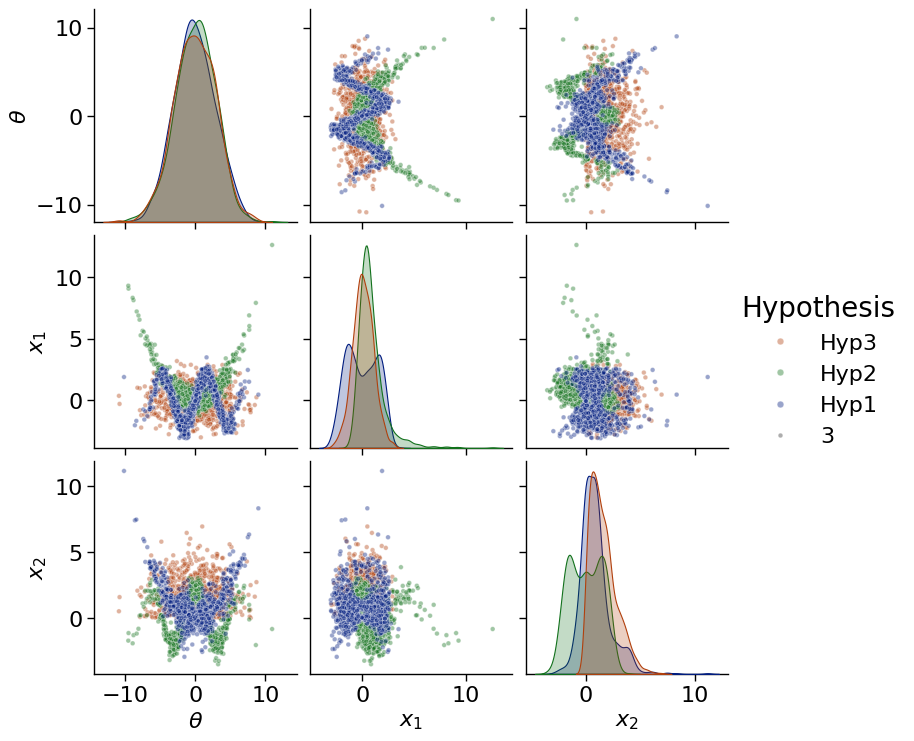

In [6]:
# Plot Hypothesis for visualization

df1 = pd.DataFrame(torch.concatenate([val_theta1, val_x1], dim=1).numpy(), columns=[r'$\theta$', r'$x_1$', r'$x_2$'])
df2 = pd.DataFrame(torch.concatenate([val_theta2, val_x2], dim=1).numpy(), columns=[r'$\theta$', r'$x_1$', r'$x_2$'])
df3 = pd.DataFrame(torch.concatenate([val_theta3, val_x3], dim=1).numpy(), columns=[r'$\theta$', r'$x_1$', r'$x_2$'])

df1["Hypothesis"] = "Hyp1"
df2["Hypothesis"] = "Hyp2"
df3["Hypothesis"] = "Hyp3"

combined_df = pd.concat([df3, df2, df1], axis=0)

plt.figure(figsize=(6, 6), dpi=500)
palette = sns.color_palette("dark", 3)
palette = [palette[1], palette[2], palette[0]]

sns.set_context("paper", rc={"axes.labelsize": 16, "xtick.labelsize": 16, "ytick.labelsize": 16, "legend.fontsize": 16, "legend.title_fontsize": 20})
sns.pairplot(combined_df, diag_kind='kde', hue='Hypothesis', plot_kws=dict(alpha=0.4, size=3, linewidth=0.5), palette=palette)
plt.show()

## Setting up the ModelTransfuser

Now we introduce the core of the COMPASS workflow: the `ModelTransfuser` (or `MTf`). <br>
This object will manage all our models, handle the training, and perform the final comparison.

First, we initialize it and tell it where to save its progress.<br>
Then, we use `add_data` to register each of our hypotheses along with their corresponding training and validation datasets.

In [7]:
# Initialize the ModelTransfuser
mtf = MTf(path="data/gaussians")

# Add the training and validation data
mtf.add_data("Hypothesis 1", theta1_n, x1_n, val_theta1_n, val_x1_n)
mtf.add_data("Hypothesis 2", theta2_n, x2_n, val_theta2_n, val_x2_n)
mtf.add_data("Hypothesis 3", theta3_n, x3_n, val_theta3_n, val_x3_n)

Data added to model Hypothesis 1
Data added to model Hypothesis 2
Data added to model Hypothesis 3


Next, we initialize the neural networks for each model. <br>
The `ModelTransfuser` will create a `ScoreBasedInferenceModel` (`SBIm`–our diffusion transformer) for each hypothesis.

We just need to specify the architecture of the models. <br>

- `sde_type`    - Specifies the type of stochastic differential equation (SDE) to use (e.g. "vesde").
- `sigma`       - The noise level for the SDE.
- `hidden_size` - The size of the hidden layers.
- `depth`       - The number of self-attention blocks.
- `num_heads`   - The number of attention heads in the transformer.
- `mlp_ratio`   - The expansion ratio of the feedforward layers to the hidden size.


In [8]:
mtf.init_models(sde_type="vesde", sigma=3, hidden_size=20, depth=4, num_heads=5,  mlp_ratio=4)

Models initialized: ['Hypothesis 1', 'Hypothesis 2', 'Hypothesis 3']


### Training the Models

With everything set up, we can now train our models. <br>
The `train_models` method will automatically train a surrogate network for each hypothesis until they converge. <br>
This is the most computationally intensive step, but it's a one-time "amortized" cost. <br>
Once the models are trained, inference is extremely fast.

`compass` is set up to utilize all available GPUs, if the `device` argument is set to `"cuda"` (default).


In [9]:
mtf.train_models(batch_size=256, device="cuda")

Model Hypothesis 1 trained
Model Hypothesis 2 trained
Model Hypothesis 3 trained


You can also add pretrained models to the `MTf` with the `add_model` method.

In [10]:
# Load the pretrained models

# sbim1 = SBIm.load("data/gaussians/Hypothesis 1.pt", device="cuda")
# sbim2 = SBIm.load("data/gaussians/Hypothesis 2.pt", device="cuda")
# sbim3 = SBIm.load("data/gaussians/Hypothesis 3.pt", device="cuda")

# mtf.add_model("Hypothesis 1", sbim1)
# mtf.add_model("Hypothesis 2", sbim2)
# mtf.add_model("Hypothesis 3", sbim3)

### Performing the Model Comparison

After training/loading the surrogate models, we can perform the model comparison and parameter inference.

First we create a new set of test data from our Hypothesis 1. <br>
These 100 samples are the observations we will use for the model comparison.

The `compare` method takes these observations and computes the posterior probabilities for each hypothesis $P(\mathcal M_i|x_{obs})$ by executing the following automated pipeline:
- **Parameter Estimation**<br>
Inferring the maximum-a-posteriori (MAP) parameters for each model.

- **Likelihood Modelling**<br>
Modelling the likelihood function under the MAP estimate.

- **Likelihood Evaluation**<br>
Evaluating the likelihood of the observations under each hypothesis.

- **Posterior Model Probability**<br>
The models are ranked based on their maximized likelihoods. 
These likelihoods are converted into posterior model probabilities, using the Akaike Information Criterion (AIC), which simplifies to a direct comparison of likelihoods if the models have the same number of parameters.

In [11]:
# Create test data
test_theta1, test_x1 = gen_data_hyp1(100)
test_x1_n = (test_x1 - data_mean[1:]) / data_std[1:]

# Compare models on test data
mtf.compare(x=test_x1_n, device="cuda", timesteps=200, method="dpm", order=1)

Comparing models: 100%|██████████| 3/3 [01:16<00:00, 25.66s/model]

Probabilities of the models after 100 observations:
Hypothesis 1: 100.00 %
Hypothesis 2:   0.00 %
Hypothesis 3:   0.00 %

Model Hypothesis 1 fits the data best with a relative support of 100.0% among the considered models.


After the analysis of the 100 observations, `compass` is 100% confident, that Hypothesis 1 fits the data best under the 3 considered models.

The results of the comparison are saved in a results dictionary as a pickle file under the earlier specified path.<br>
Under the name of the model, the dictionary contains the:
- `MAP`: The maximum a posteriori estimate of the model parameters.
- `log_probs`: The log probabilities of the observations under the model.
- `obs_probs`: The probabilities of the observations under the model.
- `AIC`: The Akaike Information Criterion, a measure of the relative quality of the model.
- `model_probs`: The probabilities of each model given the data.
- `attn_weights`: The attention weights learned by the model.

## Visualization of Results
`compass` provides easy-to-use plotting functions to visualize the results of the model comparison.

The `plot_comparison` method generates two plots:
- **Violin Plot** <br>
This shows the distribution of posterior probabilities for each model based on single observations.
We can see that for most individual data points, Hypothesis 1 (orange) is already strongly preferred.

- **Cumulative Posterior Probability Plot** <br>
This plot displays the cumulative posterior probabilities for each model as more data is observed.
The confidence in Hypothesis 1 (orange) grows with more data, while the confidence in the other hypotheses diminishes.

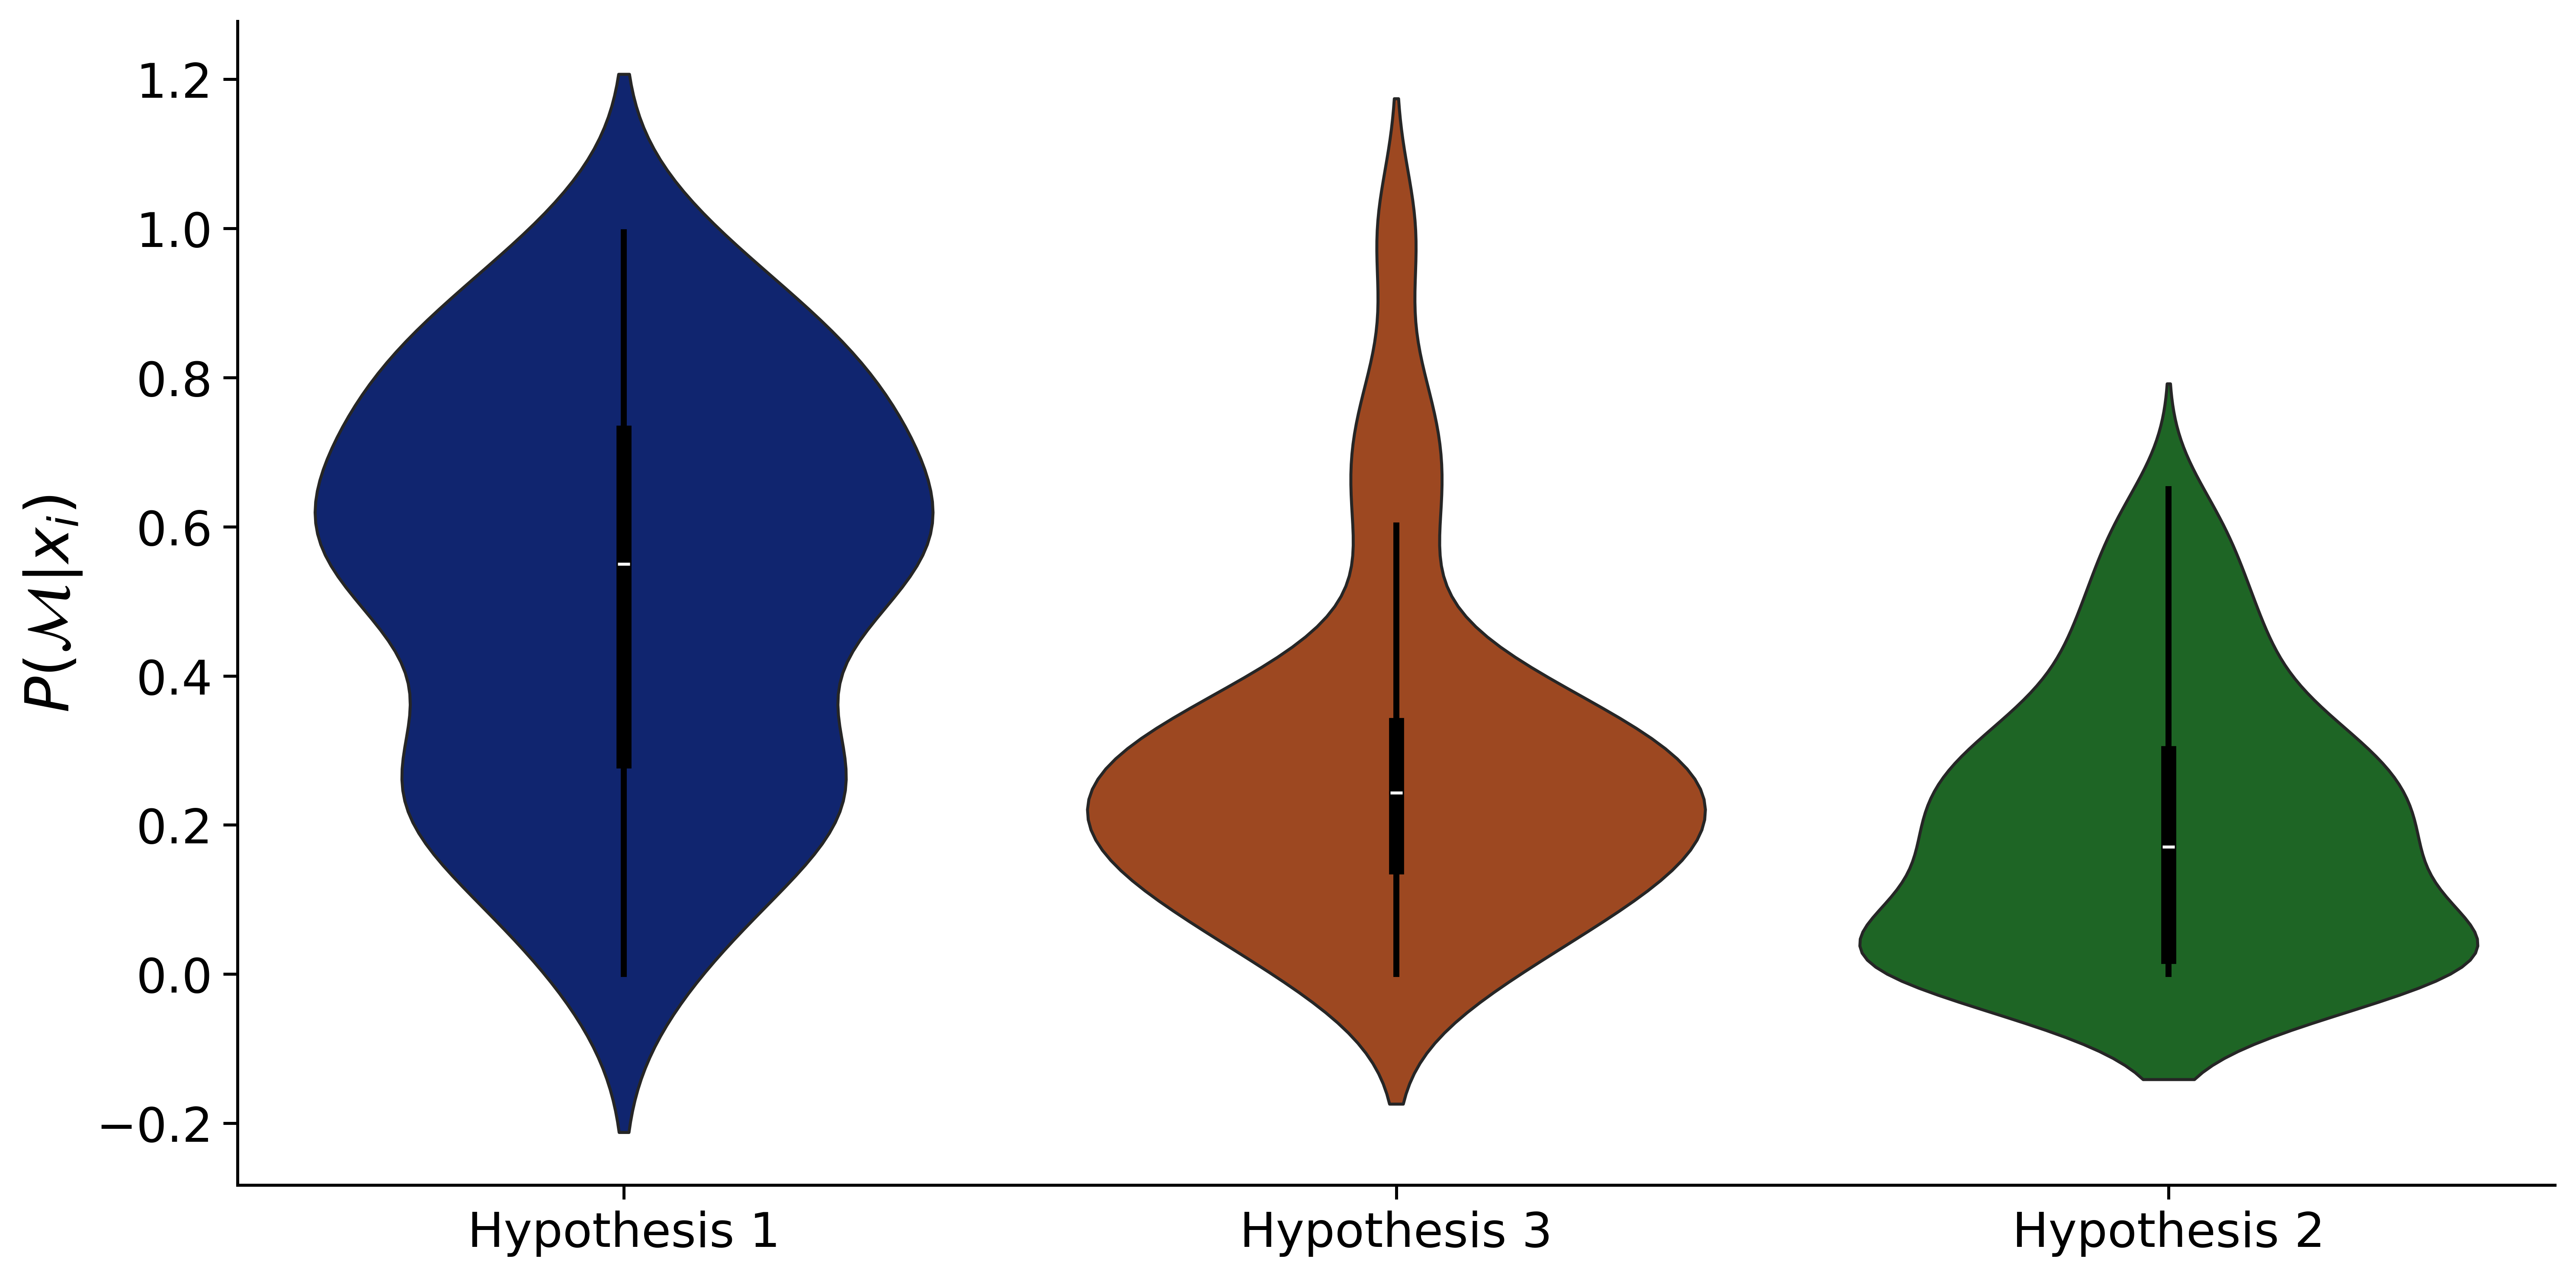

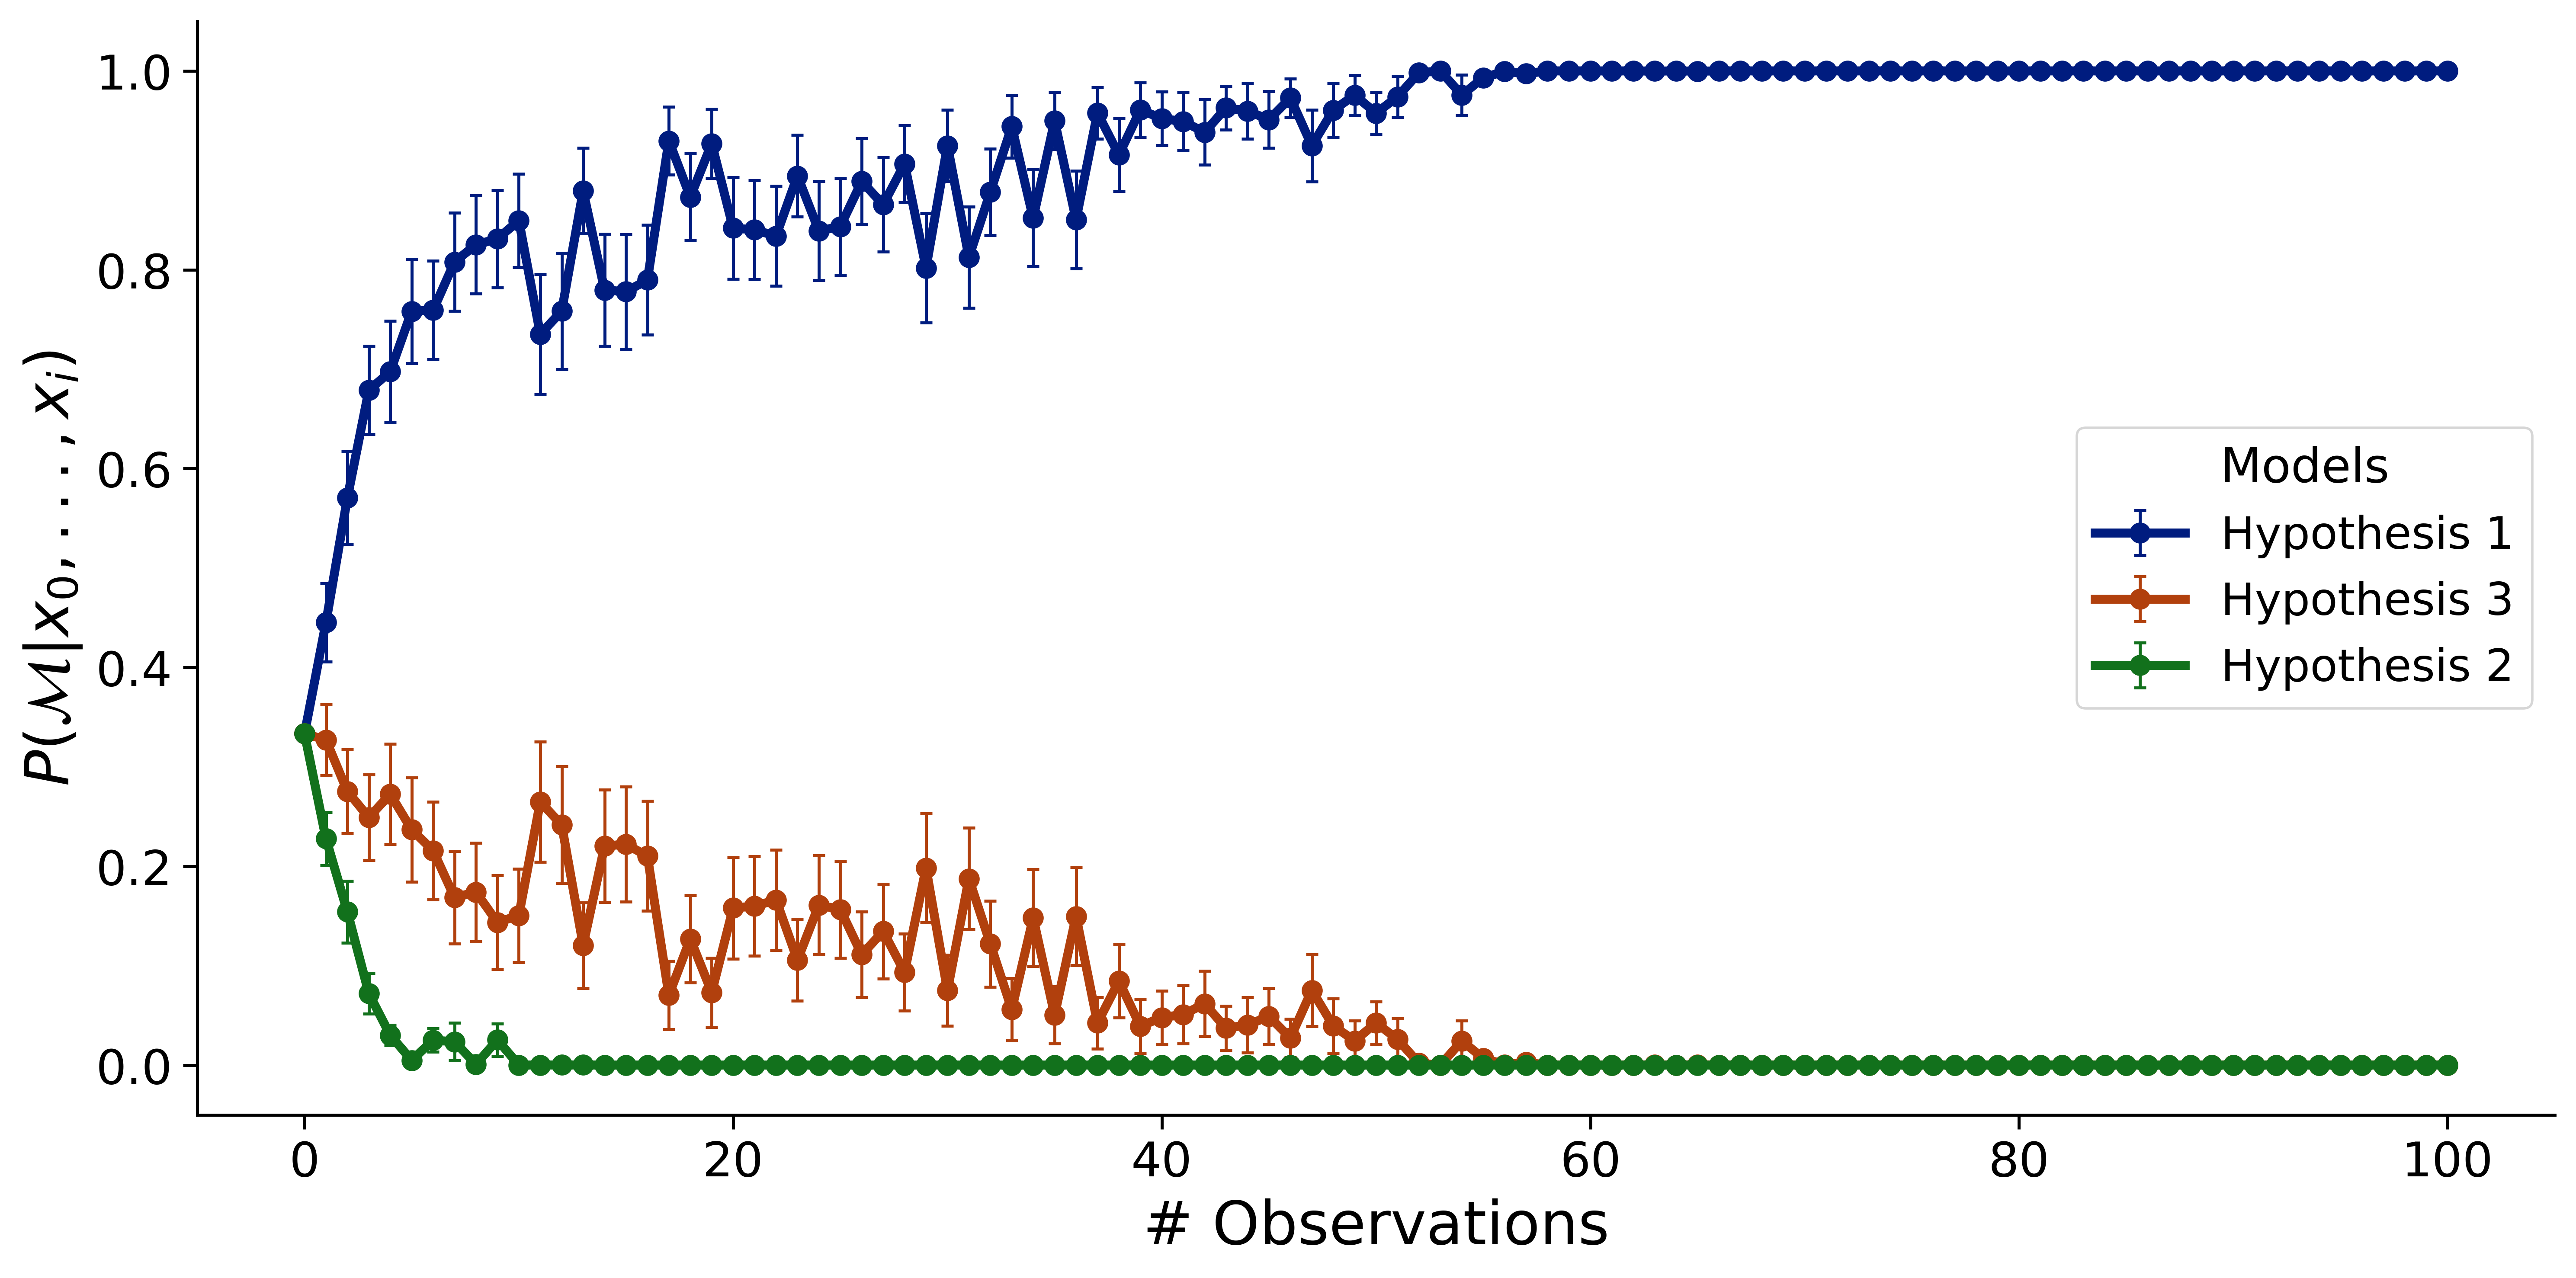

In [12]:
mtf.plot_comparison()

## Baseline Comparisons

In [20]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 1. Generate test data from ALL hypotheses
# ============================================================
N_test = 100  # observations per hypothesis

test_sets = {}
for i, (name, gen_fn) in enumerate([
    ("Hypothesis 1", gen_data_hyp1),
    ("Hypothesis 2", gen_data_hyp2),
    ("Hypothesis 3", gen_data_hyp3),
]):
    _, test_x = gen_fn(N_test)
    test_sets[name] = {"x": test_x, "true_label": i}


# ============================================================
# 2. True Marginal Likelihood (Gold Standard)
# ============================================================

def true_log_likelihood_hyp1(x, theta):
    """p(x|θ, M1): x1 ~ N(2sin(θ), 0.5²), x2 ~ N(0.1θ², (0.5|x1|)²)"""
    x1, x2 = x[:, 0], x[:, 1]

    ll_x1 = torch.distributions.Normal(
                2 * torch.sin(theta), 0.5
            ).log_prob(x1)
    
    ll_x2 = torch.distributions.Normal(
                0.1 * theta**2, 0.5 * torch.abs(x1) + 1e-8
            ).log_prob(x2)
    
    return ll_x1 + ll_x2

def true_log_likelihood_hyp2(x, theta):
    """p(x|θ, M2): x1 ~ N(2cos(θ), 0.5²), x2 ~ N(0.1θ², (0.5|x1|)²)"""
    x1, x2 = x[:, 0], x[:, 1]

    ll_x1 = torch.distributions.Normal(
                0.1 * theta**2, 0.5 
            ).log_prob(x1)
    
    ll_x2 = torch.distributions.Normal(
                2 * torch.cos(theta), 0.5
            ).log_prob(x2)
    
    return ll_x1 + ll_x2

def true_log_likelihood_hyp3(x, theta):
    """p(x|θ, M3): x1 ~ N(0, 1), x2 ~ |N(0, 2²)| — independent of theta"""
    x1, x2 = x[:, 0], x[:, 1]

    ll_x1 = torch.distributions.Normal(0.0, 1.0).log_prob(x1)
    
    dist_x2 = torch.distributions.HalfNormal(2.0, validate_args=False)
    # Set log-prob to -inf for x2 < 0, since HalfNormal is only defined for x >= 0
    ll_x2 = torch.where(
                x2 >= 0,
                dist_x2.log_prob(x2),
                torch.tensor(float('-inf'))
            )
    
    return ll_x1 + ll_x2

def compute_true_marginal_probs(test_x, K=50_000):
    """Compute p(M_i|x) for each observation via MC marginal likelihood."""
    theta_mc = 3 * torch.randn(K)
    ll_fns = [true_log_likelihood_hyp1, true_log_likelihood_hyp2, true_log_likelihood_hyp3]
    
    log_marginals = torch.zeros(test_x.shape[0], 3)
    for j, ll_fn in enumerate(ll_fns):
        for i in range(test_x.shape[0]):
            x_i = test_x[i:i+1].expand(K, -1)
            ll = ll_fn(x_i, theta_mc)
            log_marginals[i, j] = torch.logsumexp(ll, 0) - np.log(K)
    
    return torch.softmax(log_marginals, dim=1)  # (N, 3)




In [14]:
# ============================================================
# 3. Amortized Classifier
# ============================================================
def train_classifier():
    n = 100_000
    _, x1 = gen_data_hyp1(n)
    _, x2 = gen_data_hyp2(n)
    _, x3 = gen_data_hyp3(n)
    X = torch.cat([x1, x2, x3])
    y = torch.cat([torch.zeros(n), torch.ones(n), 2*torch.ones(n)]).long()
    perm = torch.randperm(len(X)); X, y = X[perm], y[perm]
    
    clf = nn.Sequential(nn.Linear(2,128), nn.ReLU(),
                        nn.Linear(128,128), nn.ReLU(),
                        nn.Linear(128,3))
    opt = torch.optim.Adam(clf.parameters(), lr=1e-3)
    for _ in range(20):
        for i in range(0, len(X), 1024):
            loss = nn.CrossEntropyLoss()(clf(X[i:i+1024]), y[i:i+1024])
            opt.zero_grad(); loss.backward(); opt.step()
    clf.eval()
    return clf

classifier = train_classifier()

def classifier_probs(clf, test_x):
    with torch.no_grad():
        return torch.softmax(clf(test_x), dim=1)




In [28]:
# ============================================================
# 4. COMPASS — run on each test set
# ============================================================
def compass_probs(mtf, test_x, hyp_names):
    """Run COMPASS comparison and extract per-observation probabilities."""
    test_x_norm = (test_x - data_mean[1:]) / data_std[1:]
    mtf.compare(x=test_x_norm, device="cuda", timesteps=500, method="dpm", order=1)
    probs = []
    for name in hyp_names:
        probs.append(torch.tensor(mtf.stats[name]["obs_probs"]))
    return torch.stack(probs, dim=1)  # (N, 3)

In [29]:
# ============================================================
# 5. Collect results for all methods × all test sets
# ============================================================
hyp_names = ["Hypothesis 1", "Hypothesis 2", "Hypothesis 3"]

results = {method: {"probs": [], "true_labels": []} 
           for method in ["True Marginal", "COMPASS", "Classifier"]}

for name, data in test_sets.items():
    test_x = data["x"]
    true_label = data["true_label"]
    
    # True marginal
    true_p = compute_true_marginal_probs(test_x)
    results["True Marginal"]["probs"].append(true_p)
    results["True Marginal"]["true_labels"].extend([true_label] * N_test)
    
    # Classifier
    clf_p = classifier_probs(classifier, test_x)
    results["Classifier"]["probs"].append(clf_p)
    results["Classifier"]["true_labels"].extend([true_label] * N_test)
    
    # COMPASS
    compass_p = compass_probs(mtf, test_x, hyp_names)
    results["COMPASS"]["probs"].append(compass_p)
    results["COMPASS"]["true_labels"].extend([true_label] * N_test)


# Stack everything
for method in results:
    results[method]["probs"] = torch.cat(results[method]["probs"], dim=0)  # (300, 3)
    results[method]["true_labels"] = torch.tensor(results[method]["true_labels"])




Comparing models: 100%|██████████| 3/3 [02:15<00:00, 45.09s/model]


Probabilities of the models after 100 observations:
Hypothesis 1: 100.00 %
Hypothesis 2:   0.00 %
Hypothesis 3:   0.00 %

Model Hypothesis 1 fits the data best with a relative support of 100.0% among the considered models.


Comparing models: 100%|██████████| 3/3 [02:14<00:00, 44.98s/model]


Probabilities of the models after 100 observations:
Hypothesis 1:   0.00 %
Hypothesis 2: 100.00 %
Hypothesis 3:   0.00 %

Model Hypothesis 2 fits the data best with a relative support of 100.0% among the considered models.


Comparing models: 100%|██████████| 3/3 [02:13<00:00, 44.66s/model]

Probabilities of the models after 100 observations:
Hypothesis 1:   0.00 %
Hypothesis 2:   0.00 %
Hypothesis 3: 100.00 %

Model Hypothesis 3 fits the data best with a relative support of 100.0% among the considered models.


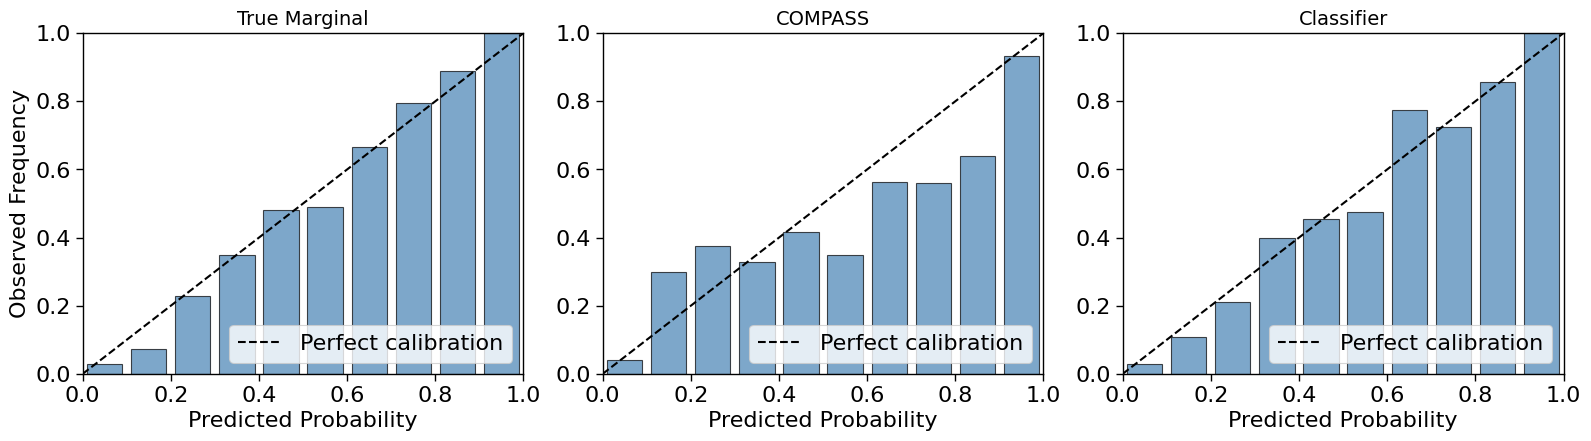

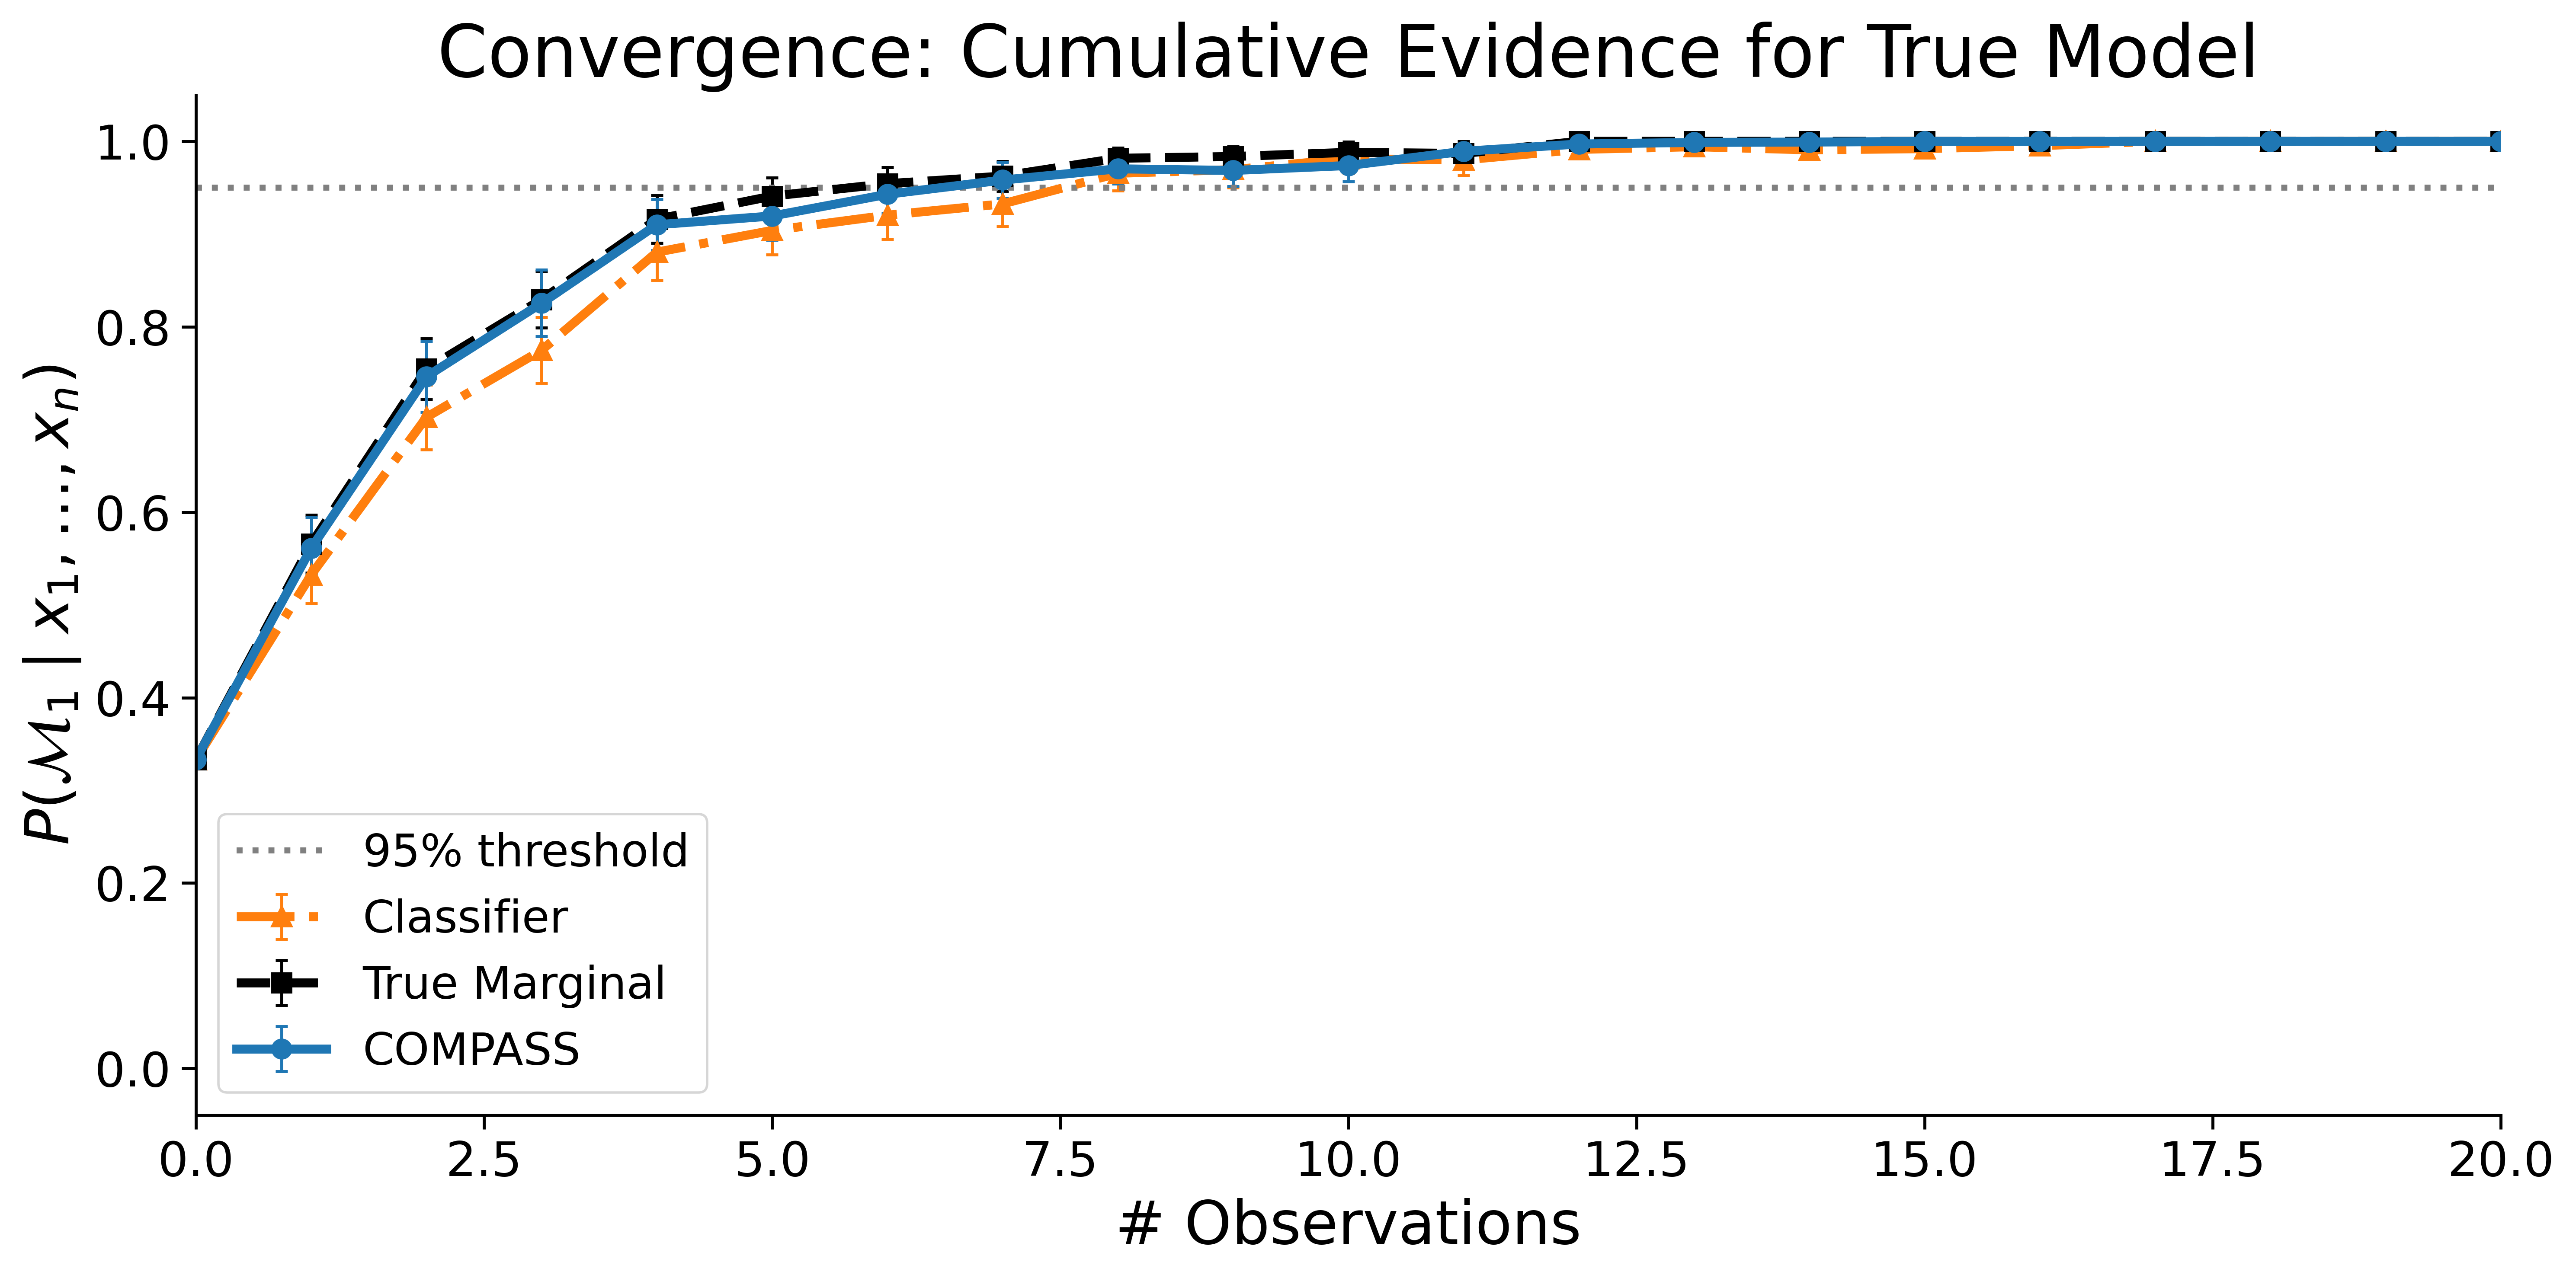

In [30]:
# ============================================================
# 8. CALIBRATION PLOT
# ============================================================
# For each method: bin the predicted probabilities, check if
# the fraction of correct predictions matches the predicted probability.

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
n_bins = 10

for ax, method in zip(axes, ["True Marginal", "COMPASS", "Classifier"]):
    probs = results[method]["probs"]
    true_labels = results[method]["true_labels"]
    
    # Collect all (predicted_prob, was_correct) pairs across all classes
    all_pred_probs = []
    all_correct = []
    for cls in range(3):
        p_cls = probs[:, cls]
        correct = (true_labels == cls).float()
        all_pred_probs.append(p_cls)
        all_correct.append(correct)
    
    all_pred_probs = torch.cat(all_pred_probs)
    all_correct = torch.cat(all_correct)
    
    # Bin
    bin_edges = torch.linspace(0, 1, n_bins + 1)
    bin_centers = []
    bin_accs = []
    bin_counts = []
    
    for i in range(n_bins):
        mask = (all_pred_probs >= bin_edges[i]) & (all_pred_probs < bin_edges[i+1])
        if mask.sum() > 0:
            bin_centers.append((bin_edges[i] + bin_edges[i+1]).item() / 2)
            bin_accs.append(all_correct[mask].mean().item())
            bin_counts.append(mask.sum().item())
    
    ax.bar(bin_centers, bin_accs, width=0.08, alpha=0.7, color='steelblue', edgecolor='k')
    ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Perfect calibration')
    ax.set_title(method, fontsize=14)
    ax.set_xlabel("Predicted Probability")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    if method == "True Marginal":
        ax.set_ylabel("Observed Frequency")
    ax.legend(loc='lower right')

plt.tight_layout()
plt.show()


# ============================================================
# 9. CONVERGENCE ANALYSIS
# ============================================================
# For data generated from Hypothesis 1 only:
# All methods share the same random permutations for a fair comparison.

N_runs = 50
N_obs = N_test  # 100

# Pre-generate shared random permutations (same for all methods)
permutations = [torch.randperm(N_obs) for _ in range(N_runs)]

colors_method = {"True Marginal": "black", "COMPASS": "#1f77b4", "Classifier": "#ff7f0e"}
markers_method = {"True Marginal": "s", "COMPASS": "o", "Classifier": "^"}
linestyles_method = {"True Marginal": "--", "COMPASS": "-", "Classifier": "-."}

fig, ax = plt.subplots(figsize=(12, 6), dpi=500)

for method in ["Classifier", "True Marginal", "COMPASS"]:
    probs = results[method]["probs"][:N_obs]   # (N_obs, 3) — Hypothesis 1 test set
    log_p = torch.log(probs + 1e-30)           # (N_obs, 3)

    avg_model_probs = []
    for perm in permutations:
        all_N_probs = []
        for i in range(0, N_obs + 1):
            if i != 0:
                idx = perm[:i]
                N_log_probs = log_p[idx, :]    # (i, 3): i observations, all models
            else:
                N_log_probs = torch.zeros(1, log_p.shape[1])
            # Sum log-probs over observations, then softmax over models
            all_N_probs.append(torch.nn.functional.softmax(N_log_probs.sum(0), 0))
        avg_model_probs.append(torch.stack(all_N_probs))  # (N_obs+1, 3)

    avg_model_probs = torch.stack(avg_model_probs)        # (N_runs, N_obs+1, 3)
    avg_mean = avg_model_probs.mean(0)                    # (N_obs+1, 3)
    avg_std  = avg_model_probs.std(0) / torch.sqrt(torch.tensor(float(N_runs)))

    true_model_idx = 0  # Hypothesis 1 is index 0
    ax.errorbar(
        torch.arange(0, N_obs + 1),
        avg_mean[:, true_model_idx],
        yerr=avg_std[:, true_model_idx],
        label=method,
        marker=markers_method[method],
        markersize=6,
        linewidth=3,
        elinewidth=1,
        capsize=2,
        color=colors_method[method],
        ls=linestyles_method[method],
    )

ax.axhline(y=0.95, color='gray', ls=':', label='95% threshold', linewidth=2)
ax.set_xlabel("# Observations", fontsize=20)
ax.set_ylabel(r"$P(\mathcal{M}_1 \mid x_1, \ldots, x_n)$", fontsize=20)
ax.set_title("Convergence: Cumulative Evidence for True Model", fontsize=24)
ax.legend(fontsize=15, frameon=True)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.set_ylim(-0.05, 1.05)
ax.set_xlim(0, 20)
sns.despine()
plt.tight_layout()
plt.show()


In [18]:
# ============================================================
# 10. COMPASS HYPERPARAMETER SWEEP FOR CONVERGENCE
# ============================================================
# Compare cumulative posterior convergence for different DPM settings.


timesteps_grid = [50, 100, 200, 300, 400, 500, 1000]
orders_grid = [1]

# Reuse Hypothesis 1 test observations from the earlier benchmark setup
test_x_h1 = test_sets["Hypothesis 1"]["x"]
test_x_h1_norm = (test_x_h1 - data_mean[1:]) / data_std[1:]
N_obs_cfg = test_x_h1.shape[0]

# Use the same number of random permutations as above for consistency
N_runs_cfg = N_runs
permutations_cfg = [torch.randperm(N_obs_cfg) for _ in range(N_runs_cfg)]

# Cache per-observation probabilities for each DPM config
compass_cfg_probs = {}
for ts in timesteps_grid:
    for order in orders_grid:
        mtf.compare(
            x=test_x_h1_norm,
            device="cuda",
            timesteps=ts,
            method="dpm",
            order=order,
        )
        probs_cfg = []
        for name in hyp_names:
            probs_cfg.append(torch.tensor(mtf.stats[name]["obs_probs"]))
        compass_cfg_probs[(ts, order)] = torch.stack(probs_cfg, dim=1)  # (N_obs, 3)


Comparing models: 100%|██████████| 3/3 [00:44<00:00, 14.75s/model]


Probabilities of the models after 100 observations:
Hypothesis 1: 100.00 %
Hypothesis 2:   0.00 %
Hypothesis 3:   0.00 %

Model Hypothesis 1 fits the data best with a relative support of 100.0% among the considered models.


Comparing models: 100%|██████████| 3/3 [00:53<00:00, 17.90s/model]


Probabilities of the models after 100 observations:
Hypothesis 1: 100.00 %
Hypothesis 2:   0.00 %
Hypothesis 3:   0.00 %

Model Hypothesis 1 fits the data best with a relative support of 100.0% among the considered models.


Comparing models: 100%|██████████| 3/3 [01:14<00:00, 24.98s/model]


...

Probabilities of the models after 100 observations:
Hypothesis 1: 100.00 %
Hypothesis 2:   0.00 %
Hypothesis 3:   0.00 %

Model Hypothesis 1 fits the data best with a relative support of 100.0% among the considered models.


Comparing models: 100%|██████████| 3/3 [02:15<00:00, 45.24s/model]


Probabilities of the models after 100 observations:
Hypothesis 1: 100.00 %
Hypothesis 2:   0.00 %
Hypothesis 3:   0.00 %

Model Hypothesis 1 fits the data best with a relative support of 100.0% among the considered models.


Comparing models: 100%|██████████| 3/3 [03:52<00:00, 77.54s/model]

Probabilities of the models after 100 observations:
Hypothesis 1: 100.00 %
Hypothesis 2:   0.00 %
Hypothesis 3:   0.00 %

Model Hypothesis 1 fits the data best with a relative support of 100.0% among the considered models.


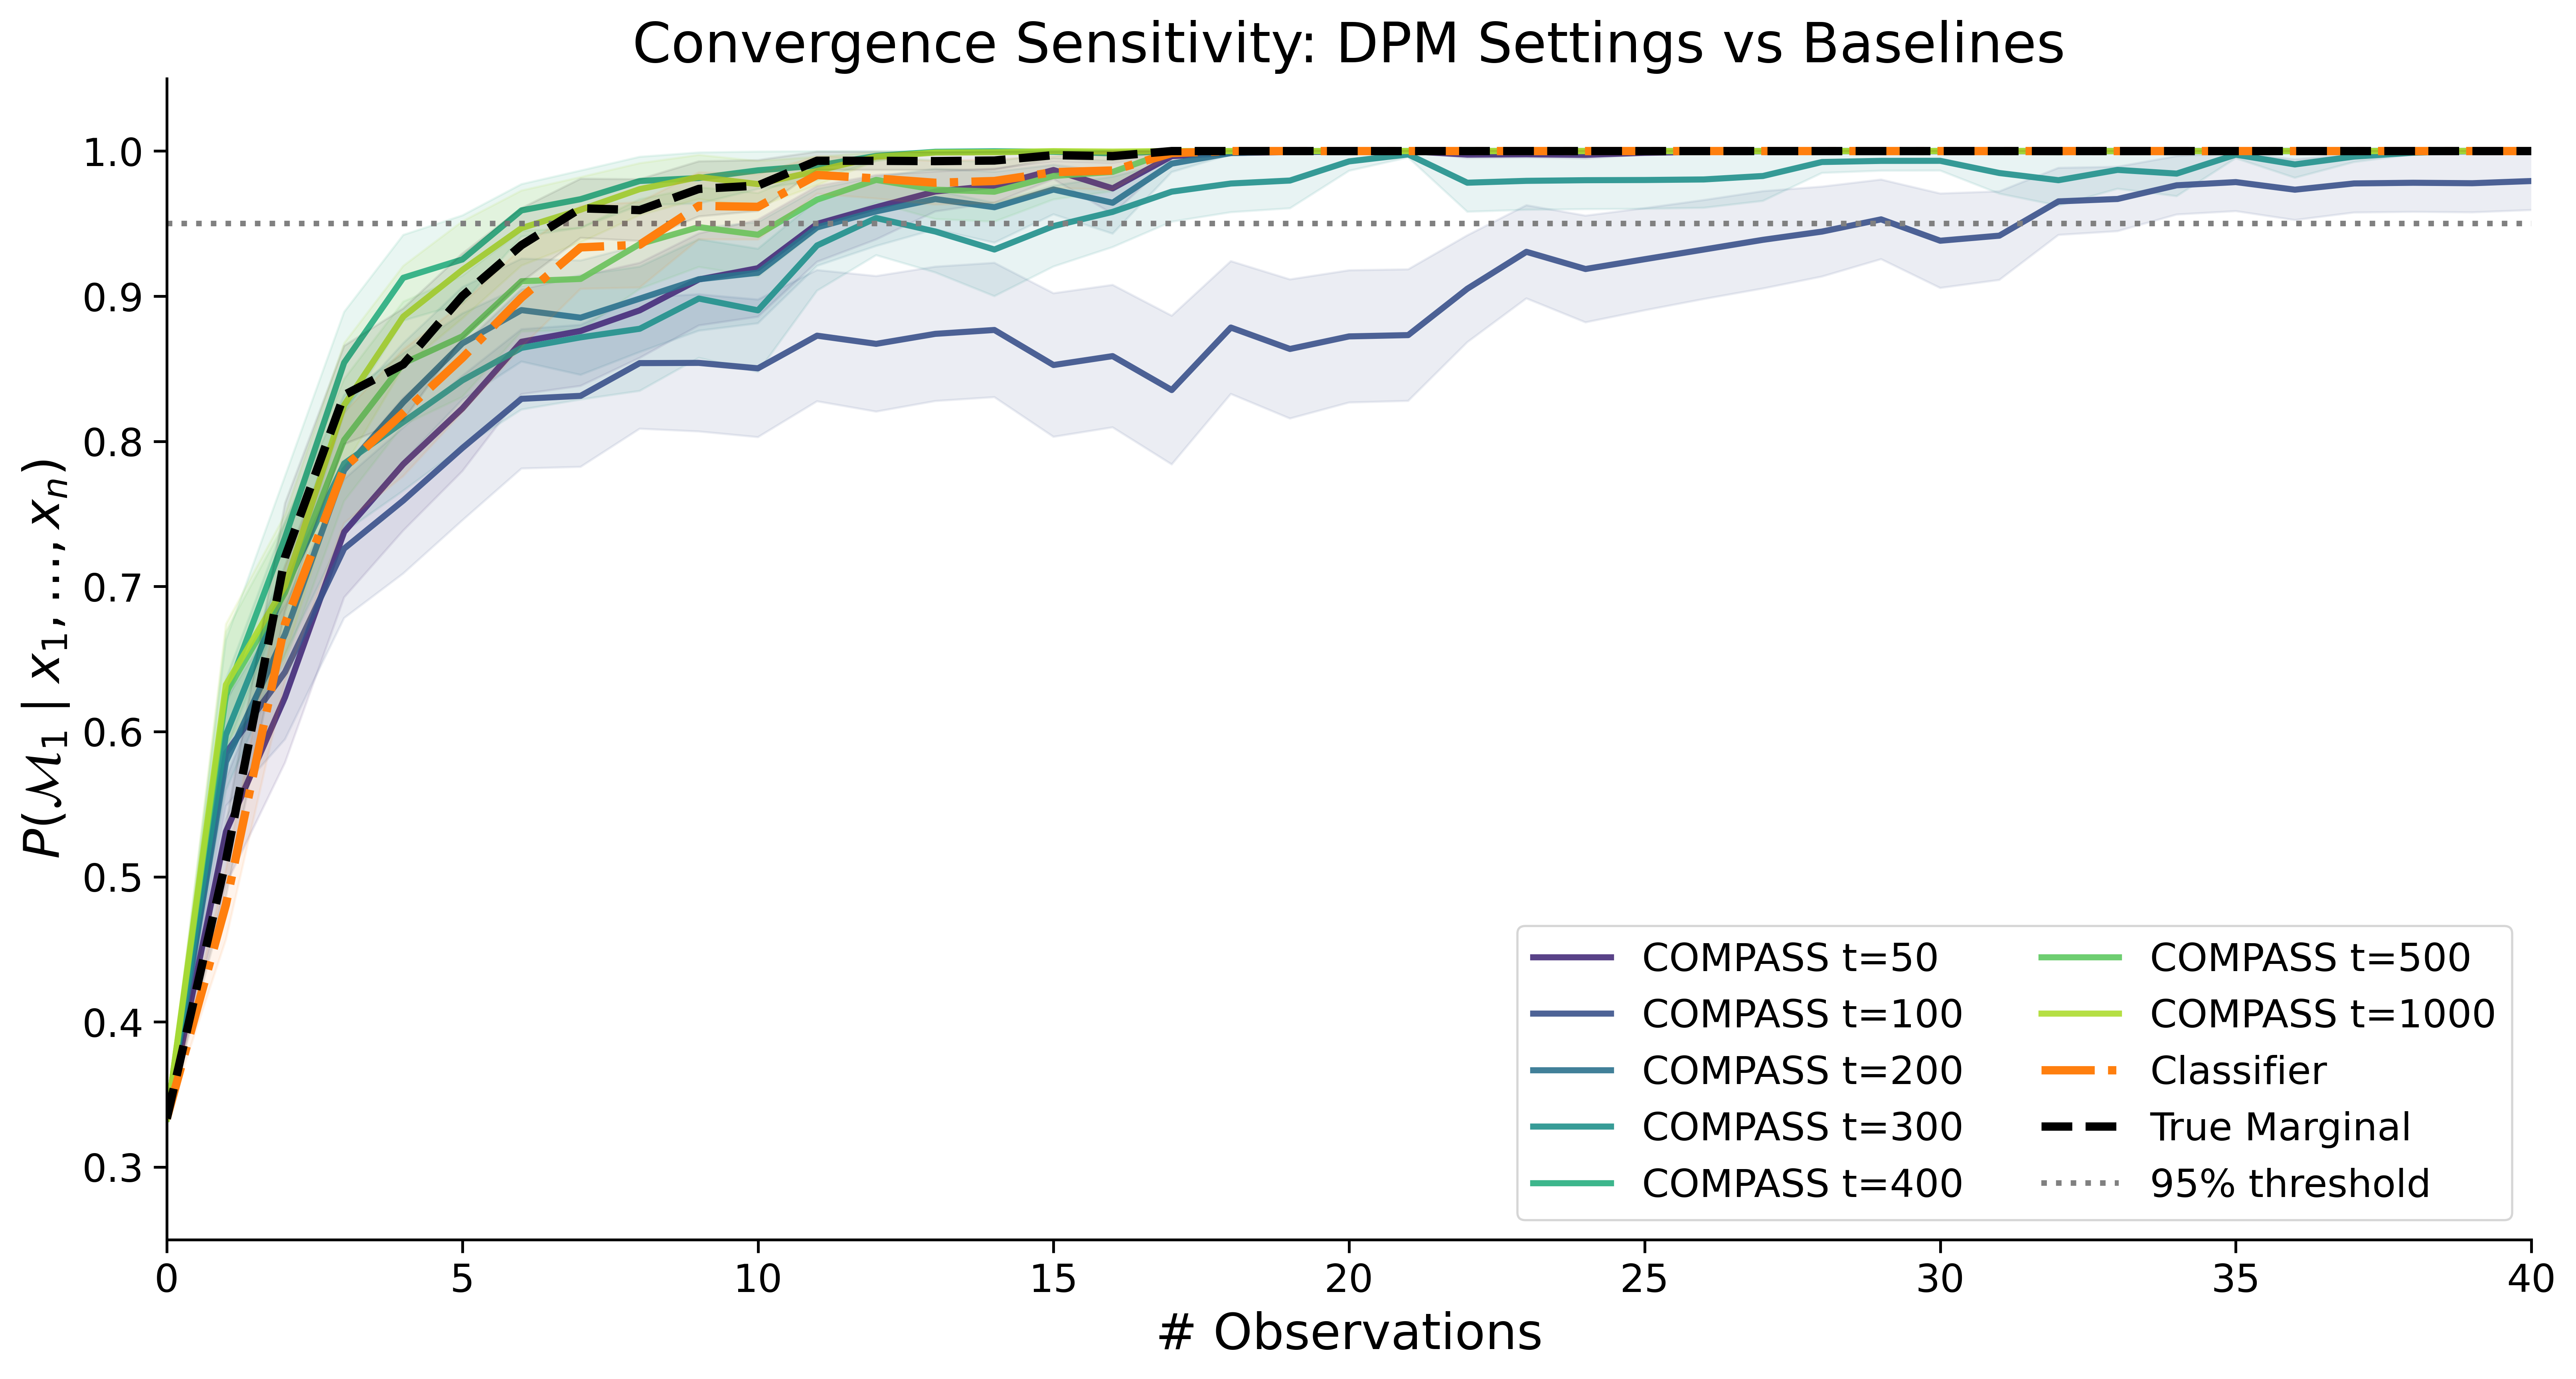

In [31]:
def cumulative_true_model_curve(probs, permutations, true_model_idx=0):
    """Compute mean and standard error of cumulative model posterior across permutations."""
    log_p = torch.log(probs + 1e-30)
    runs = []
    
    for perm in permutations:
        cum_probs = []
        for i in range(N_obs_cfg + 1):
            if i == 0:
                summed = torch.zeros(log_p.shape[1])
            else:
                idx = perm[:i]
                summed = log_p[idx, :].sum(0)
            cum_probs.append(torch.nn.functional.softmax(summed, dim=0))
        runs.append(torch.stack(cum_probs))  # (N_obs+1, 3)
    
    runs = torch.stack(runs)  # (N_runs, N_obs+1, 3)
    mean = runs.mean(0)
    stderr = runs.std(0) / torch.sqrt(torch.tensor(float(runs.shape[0])))
    return mean[:, true_model_idx], stderr[:, true_model_idx]


# Plot: DPM settings + baseline methods
fig, ax = plt.subplots(figsize=(13, 7), dpi=500)
x_axis = torch.arange(0, N_obs_cfg + 1)

# DPM styling: color = timesteps, line style = solver order
color_map = sns.color_palette("viridis", n_colors=len(timesteps_grid))
line_styles = {1: "-", 2: "--", 3: ":"}

for c_idx, ts in enumerate(timesteps_grid):
    for order in orders_grid[:1]:
        probs = compass_cfg_probs[(ts, order)][:N_obs_cfg]
        mean_curve, se_curve = cumulative_true_model_curve(
            probs=probs,
            permutations=permutations_cfg,
            true_model_idx=0,
        )
        
        label = f"COMPASS t={ts}"
        ax.plot(
            x_axis,
            mean_curve,
            color=color_map[c_idx],
            linestyle=line_styles[order],
            linewidth=2.2,
            alpha=0.9,
            label=label,
        )

        ax.fill_between(
            x_axis.numpy(),
            (mean_curve - se_curve).numpy(),
            (mean_curve + se_curve).numpy(),
            color=color_map[c_idx],
            alpha=0.1,
        )

# Baseline methods for direct comparison on the same convergence metric
baseline_styles = {
    "True Marginal": {"color": "black", "linestyle": "--", "marker": "s"},
    "Classifier": {"color": "#ff7f0e", "linestyle": "-.", "marker": "^"},
}

for method in ["Classifier", "True Marginal"]:
    probs_method = results[method]["probs"][:N_obs_cfg]
    mean_curve, se_curve = cumulative_true_model_curve(
        probs=probs_method,
        permutations=permutations_cfg,
        true_model_idx=0,
    )
    style = baseline_styles[method]
    ax.plot(
        x_axis,
        mean_curve,
        color=style["color"],
        linestyle=style["linestyle"],
        linewidth=3,
        label=method,
        zorder=6,
    )
    ax.fill_between(
        x_axis.numpy(),
        (mean_curve - se_curve).numpy(),
        (mean_curve + se_curve).numpy(),
        color=style["color"],
        alpha=0.08,
        zorder=5,
    )

ax.axhline(y=0.95, color="gray", ls=":", linewidth=2, label="95% threshold")
ax.set_xlabel("# Observations", fontsize=18)
ax.set_ylabel(r"$P(\mathcal{M}_1 \mid x_1, \ldots, x_n)$", fontsize=18)
ax.set_title("Convergence Sensitivity: DPM Settings vs Baselines", fontsize=20)
ax.set_ylim(0.25, 1.05)
ax.set_xlim(0, 40)
ax.tick_params(axis="both", which="major", labelsize=14)
ax.legend(fontsize=14, frameon=True, ncol=2, loc="lower right")
sns.despine()
plt.tight_layout()
plt.show()